In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
import time, random, os, sys
from typing import Callable, Dict, List, Set, Any, Optional, Union, Tuple
from collections import defaultdict
import itertools

# Dynamic path allocation
current_dir = os.getcwd()
project_path = os.path.abspath(os.path.join(current_dir, "..", ".."))
sys.path.append(project_path)

from algorithms.compute_PC import compute_pc

In [ ]:
import math
import random
import networkx as nx
import matplotlib.pyplot as plt


def visualize_terminal_batches(
  G,
  terminal_batches,
  layout_seed=1,
  node_size=220,
  font_size=8,
  show_labels=True
):
  position = nx.spring_layout(G, seed=layout_seed)

  terminal_to_batch = {}
  for batch_idx, terminal_batch in enumerate(terminal_batches):
    for terminal_node in terminal_batch:
      terminal_to_batch[terminal_node] = batch_idx

  terminal_nodes = set(terminal_to_batch.keys())
  non_terminal_nodes = [node for node in G.nodes() if node not in terminal_nodes]

  plt.figure(figsize=(10, 8))

  nx.draw_networkx_edges(
    G,
    position,
    alpha=0.35
  )

  nx.draw_networkx_nodes(
    G,
    position,
    nodelist=non_terminal_nodes,
    node_color="lightgray",
    node_size=node_size
  )

  color_map = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "olive",
    "cyan",
    "magenta"
  ]

  for batch_idx, terminal_batch in enumerate(terminal_batches):
    batch_color = color_map[batch_idx % len(color_map)]

    nx.draw_networkx_nodes(
      G,
      position,
      nodelist=terminal_batch,
      node_color=batch_color,
      node_size=node_size + 80,
      edgecolors="black",
      linewidths=1.2,
      label=f"batch {batch_idx + 1}"
    )

  if show_labels:
    nx.draw_networkx_labels(
      G,
      position,
      font_size=font_size
    )

  cross_batch_edges = []
  for first_node, second_node in G.edges():
    first_is_terminal = first_node in terminal_to_batch
    second_is_terminal = second_node in terminal_to_batch

    if first_is_terminal and second_is_terminal:
      if terminal_to_batch[first_node] != terminal_to_batch[second_node]:
        cross_batch_edges.append((first_node, second_node))

  if cross_batch_edges:
    nx.draw_networkx_edges(
      G,
      position,
      edgelist=cross_batch_edges,
      width=2.5,
      style="dashed",
      edge_color="black"
    )

  plt.legend()
  plt.title("Terminal batches on graph")
  plt.axis("off")
  plt.tight_layout()
  plt.show()

def find_cross_batch_terminal_edges(G, terminal_batches):
  terminal_to_batch = {}

  for batch_idx, terminal_batch in enumerate(terminal_batches):
    for terminal_node in terminal_batch:
      terminal_to_batch[terminal_node] = batch_idx

  cross_batch_edges = []

  for first_node, second_node in G.edges():
    if first_node in terminal_to_batch and second_node in terminal_to_batch:
      if terminal_to_batch[first_node] != terminal_to_batch[second_node]:
        cross_batch_edges.append((first_node, second_node))

  return cross_batch_edges

In [77]:
import math
import random
import networkx as nx


def compute_max_batch_size(terminal_count):
  return min(5, max(1, int(math.floor(0.15 * terminal_count))))


def is_partition_possible(terminal_count, min_batch_size, max_batch_size):
  if min_batch_size > max_batch_size:
    return False

  allowed_sizes = list(range(min_batch_size, max_batch_size + 1))

  reachable = [False] * (terminal_count + 1)
  reachable[0] = True

  for current_sum in range(terminal_count + 1):
    if not reachable[current_sum]:
      continue

    for batch_size in allowed_sizes:
      next_sum = current_sum + batch_size
      if next_sum <= terminal_count:
        reachable[next_sum] = True

  return reachable[terminal_count]


def generate_batch_sizes(
  terminal_count,
  min_batch_size,
  max_batch_size,
  distribution="uniform",
  bias_large=False,
  random_generator=None
):
  if random_generator is None:
    random_generator = random.Random()

  allowed_sizes = list(range(min_batch_size, max_batch_size + 1))

  if distribution == "uniform":
    weights = [1.0 for _ in allowed_sizes]

  elif distribution == "normal-like":
    center = (min_batch_size + max_batch_size) / 2.0
    sigma = max(0.75, (max_batch_size - min_batch_size + 1) / 2.0)
    weights = [
      math.exp(-((batch_size - center) ** 2) / (2.0 * sigma * sigma))
      for batch_size in allowed_sizes
    ]

  else:
    raise ValueError("distribution must be 'uniform' or 'normal-like'")

  if bias_large:
    weights = [
      base_weight * (1.0 + batch_size)
      for batch_size, base_weight in zip(allowed_sizes, weights)
    ]

  batch_sizes = []
  remaining = terminal_count

  while remaining > 0:
    feasible_sizes = [
      batch_size
      for batch_size in allowed_sizes
      if batch_size <= remaining
      and is_partition_possible(
        remaining - batch_size,
        min_batch_size,
        max_batch_size
      )
    ]

    if not feasible_sizes:
      raise RuntimeError("No feasible next batch size found")

    feasible_weights = [
      weights[allowed_sizes.index(batch_size)]
      for batch_size in feasible_sizes
    ]

    chosen_batch_size = random_generator.choices(
      feasible_sizes,
      weights=feasible_weights,
      k=1
    )[0]

    batch_sizes.append(chosen_batch_size)
    remaining -= chosen_batch_size

  return batch_sizes


def assign_terminal_batches(
  G,
  batch_sizes,
  random_generator=None,
  max_seed_trials=300
):
  if random_generator is None:
    random_generator = random.Random()

  assigned_terminals = set()
  terminal_batches = []
  all_nodes = list(G.nodes())

  for batch_size in batch_sizes:
    success = False

    for _ in range(max_seed_trials):
      seed_node = random_generator.choice(all_nodes)

      if seed_node in assigned_terminals:
        continue

      candidate_batch = []
      queue = [seed_node]
      visited = set()

      while queue and len(candidate_batch) < batch_size:
        current_node = queue.pop(0)

        if current_node in visited:
          continue
        visited.add(current_node)

        if current_node in assigned_terminals:
          continue

        has_cross_batch_terminal_edge = any(
          neighbor in assigned_terminals
          for neighbor in G.neighbors(current_node)
        )

        if has_cross_batch_terminal_edge:
          continue

        candidate_batch.append(current_node)

        for neighbor in G.neighbors(current_node):
          if neighbor not in visited:
            queue.append(neighbor)

      if len(candidate_batch) == batch_size:
        terminal_batches.append(candidate_batch)
        assigned_terminals.update(candidate_batch)
        success = True
        break

    if not success:
      return None

  return terminal_batches


def generate_terminals_with_fallback(
  G,
  terminal_count,
  distribution="uniform",
  random_seed=None,
  max_assignment_retries=20
):
  random_generator = random.Random(random_seed)

  base_max_batch_size = compute_max_batch_size(terminal_count)

  # Internal settings only, not user-facing parameters.
  max_seed_trials = 300
  hard_max_batch_size = int(terminal_count / 2)

  for current_max_batch_size in range(
    base_max_batch_size,
    hard_max_batch_size + 1
  ):
    for current_min_batch_size in range(1, current_max_batch_size + 1):
      if not is_partition_possible(
        terminal_count,
        current_min_batch_size,
        current_max_batch_size
      ):
        continue

      for _ in range(max_assignment_retries):
        batch_sizes = generate_batch_sizes(
          terminal_count=terminal_count,
          min_batch_size=current_min_batch_size,
          max_batch_size=current_max_batch_size,
          distribution=distribution,
          bias_large=True,
          random_generator=random_generator
        )

        terminal_batches = assign_terminal_batches(
          G=G,
          batch_sizes=batch_sizes,
          random_generator=random_generator,
          max_seed_trials=max_seed_trials
        )

        if terminal_batches is not None:
          terminals = [node for batch in terminal_batches for node in batch]
          return {
            "terminals": terminals,
            "terminal_batches": terminal_batches,
            "batch_sizes": batch_sizes,
            "min_batch_size": current_min_batch_size,
            "max_batch_size": current_max_batch_size,
            "base_max_batch_size": base_max_batch_size,
            "used_large_bias": True
          }

      for _ in range(max_assignment_retries):
        batch_sizes = generate_batch_sizes(
          terminal_count=terminal_count,
          min_batch_size=current_min_batch_size,
          max_batch_size=current_max_batch_size,
          distribution=distribution,
          bias_large=True,
          random_generator=random_generator
        )

        terminal_batches = assign_terminal_batches(
          G=G,
          batch_sizes=batch_sizes,
          random_generator=random_generator,
          max_seed_trials=max_seed_trials
        )

        if terminal_batches is not None:
          terminals = [node for batch in terminal_batches for node in batch]
          return {
            "terminals": terminals,
            "terminal_batches": terminal_batches,
            "batch_sizes": batch_sizes,
            "min_batch_size": current_min_batch_size,
            "max_batch_size": current_max_batch_size,
            "base_max_batch_size": base_max_batch_size,
            "used_large_bias": True
          }

  raise RuntimeError("Failed to generate terminal batches with fallback policy")

Edges: 215
batch sizes: [6, 6, 5, 4, 4, 4, 4, 6, 6, 5]
min batch size used: 4
max batch size: 6
used large-bias fallback: True
terminal batches: [[81, 8, 17, 26, 31, 51], [88, 15, 37, 50, 62, 1], [2, 9, 63, 86, 7], [58, 59, 66, 71], [72, 0, 10, 14], [11, 23, 33, 32], [96, 38, 61, 65], [12, 45, 40, 64, 76, 98], [5, 35, 90, 68, 80, 67], [4, 79, 97, 41, 55]]
terminals: [81, 8, 17, 26, 31, 51, 88, 15, 37, 50, 62, 1, 2, 9, 63, 86, 7, 58, 59, 66, 71, 72, 0, 10, 14, 11, 23, 33, 32, 96, 38, 61, 65, 12, 45, 40, 64, 76, 98, 5, 35, 90, 68, 80, 67, 4, 79, 97, 41, 55]
cross-batch terminal edges: []


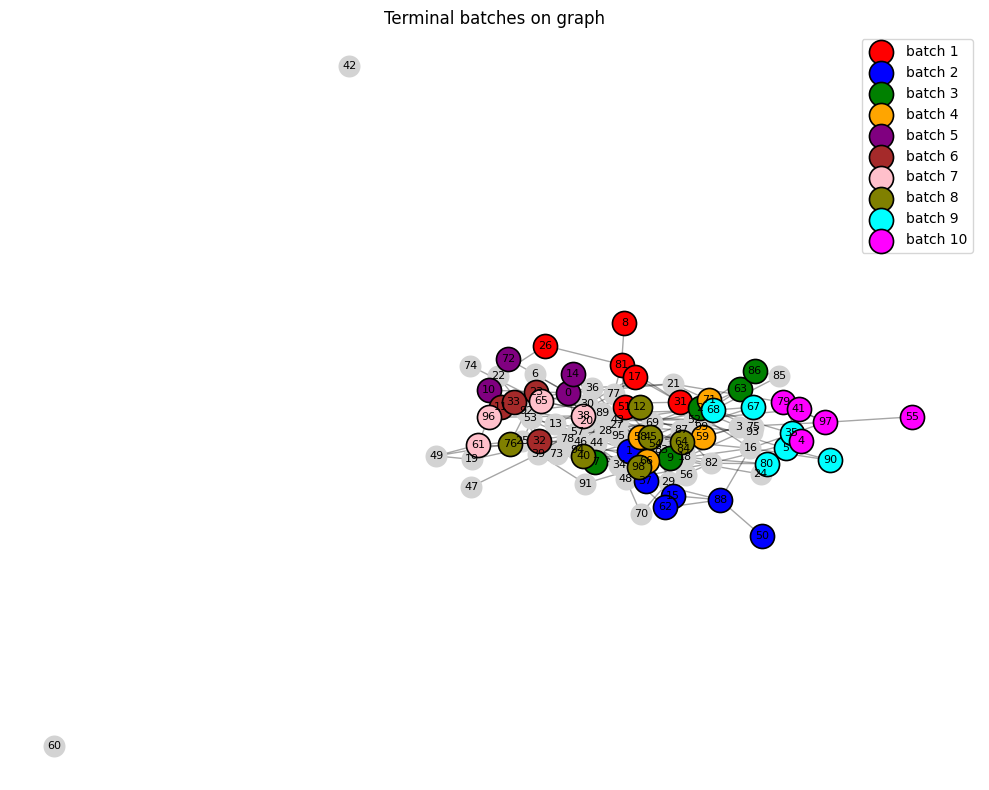

batch sizes: [6, 6, 5, 6, 6, 6, 5, 6, 4]
min batch size used: 4
max batch size: 6
used large-bias fallback: True
terminal batches: [[91, 9, 39, 2, 7, 24], [59, 3, 54, 58, 66, 71], [8, 81, 17, 26, 51], [36, 0, 33, 10, 14, 57], [40, 45, 76, 12, 34, 56], [15, 88, 16, 50, 90, 93], [61, 94, 96, 98, 38], [70, 48, 44, 82, 4, 79], [85, 68, 35, 67]]
terminals: [91, 9, 39, 2, 7, 24, 59, 3, 54, 58, 66, 71, 8, 81, 17, 26, 51, 36, 0, 33, 10, 14, 57, 40, 45, 76, 12, 34, 56, 15, 88, 16, 50, 90, 93, 61, 94, 96, 98, 38, 70, 48, 44, 82, 4, 79, 85, 68, 35, 67]
cross-batch terminal edges: []


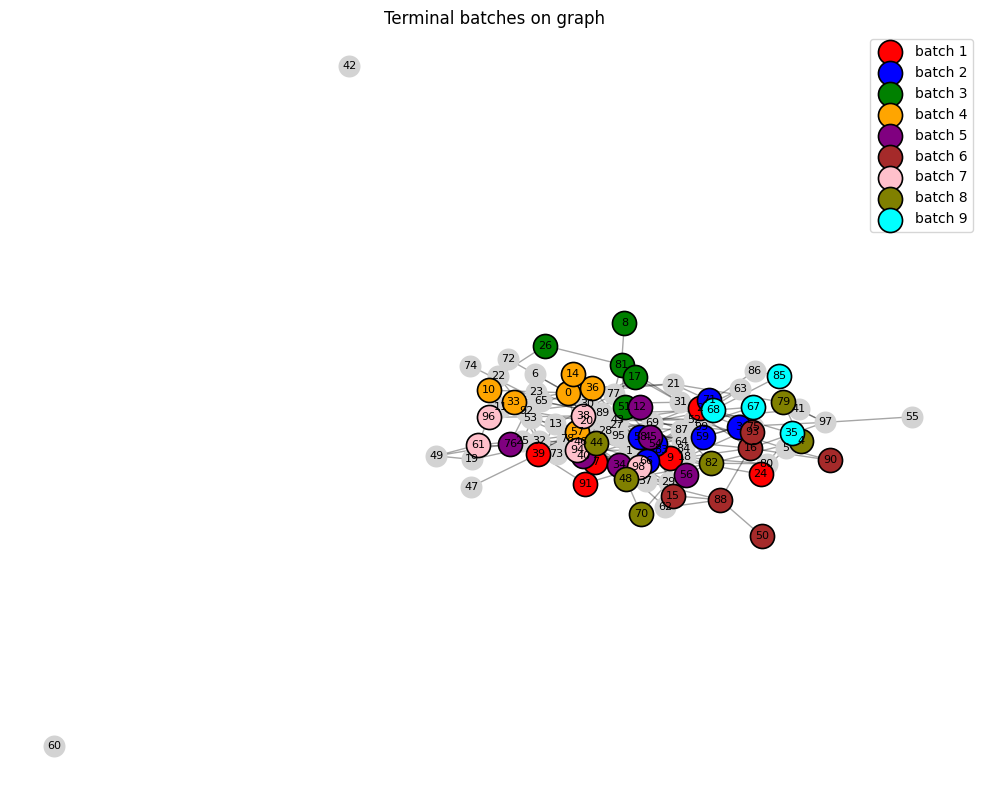

batch sizes: [5, 6, 6, 5, 6, 6, 6, 5, 5]
min batch size used: 5
max batch size: 6
used large-bias fallback: True
terminal batches: [[5, 24, 35, 52, 90], [94, 32, 61, 69, 83, 98], [40, 76, 28, 92, 1, 13], [36, 21, 79, 4, 97], [44, 48, 89, 70, 12, 14], [66, 59, 95, 78, 7, 19], [72, 22, 26, 81, 8, 17], [88, 37, 50, 62, 56], [2, 86, 87, 85, 67]]
terminals: [5, 24, 35, 52, 90, 94, 32, 61, 69, 83, 98, 40, 76, 28, 92, 1, 13, 36, 21, 79, 4, 97, 44, 48, 89, 70, 12, 14, 66, 59, 95, 78, 7, 19, 72, 22, 26, 81, 8, 17, 88, 37, 50, 62, 56, 2, 86, 87, 85, 67]
cross-batch terminal edges: []


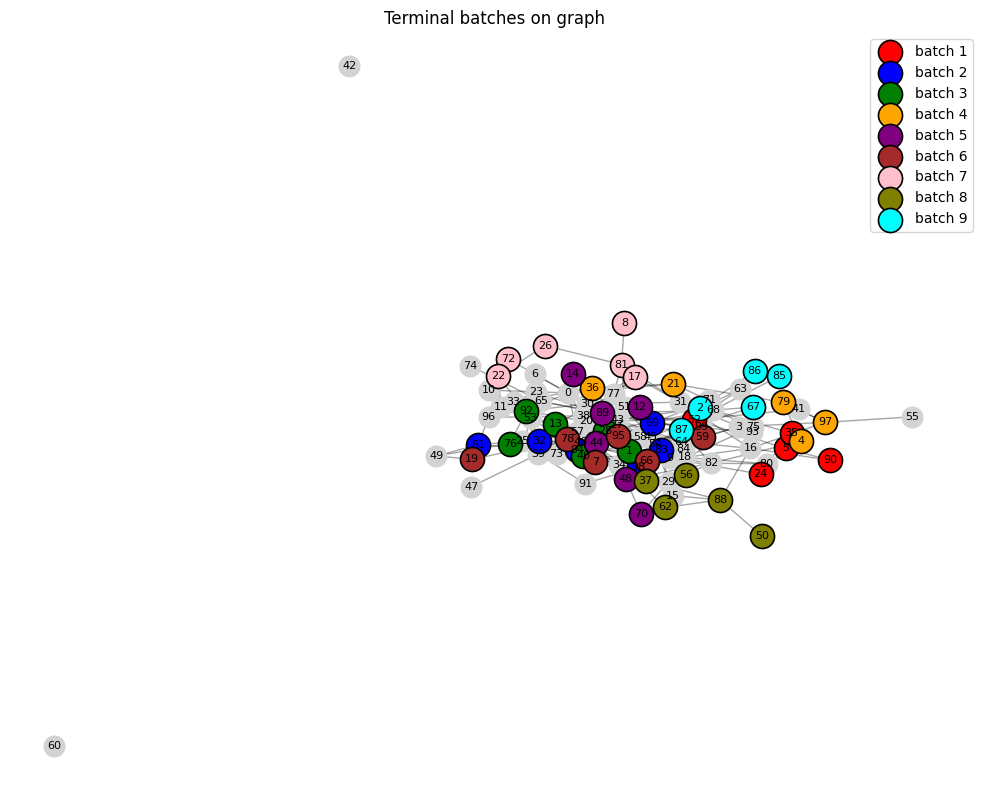

batch sizes: [5, 5, 4, 3, 5, 3, 2, 3, 5, 5, 5, 3, 2]
min batch size used: 2
max batch size: 5
used large-bias fallback: True
terminal batches: [[10, 0, 53, 14, 20], [81, 8, 17, 26, 31], [93, 69, 9, 65], [40, 18, 45], [33, 11, 23, 43, 73], [5, 35, 90], [86, 85], [15, 88, 37], [19, 49, 78, 61, 38], [55, 97, 41, 79, 4], [58, 28, 59, 13, 66], [70, 48, 44], [87, 67]]
terminals: [10, 0, 53, 14, 20, 81, 8, 17, 26, 31, 93, 69, 9, 65, 40, 18, 45, 33, 11, 23, 43, 73, 5, 35, 90, 86, 85, 15, 88, 37, 19, 49, 78, 61, 38, 55, 97, 41, 79, 4, 58, 28, 59, 13, 66, 70, 48, 44, 87, 67]
cross-batch terminal edges: []


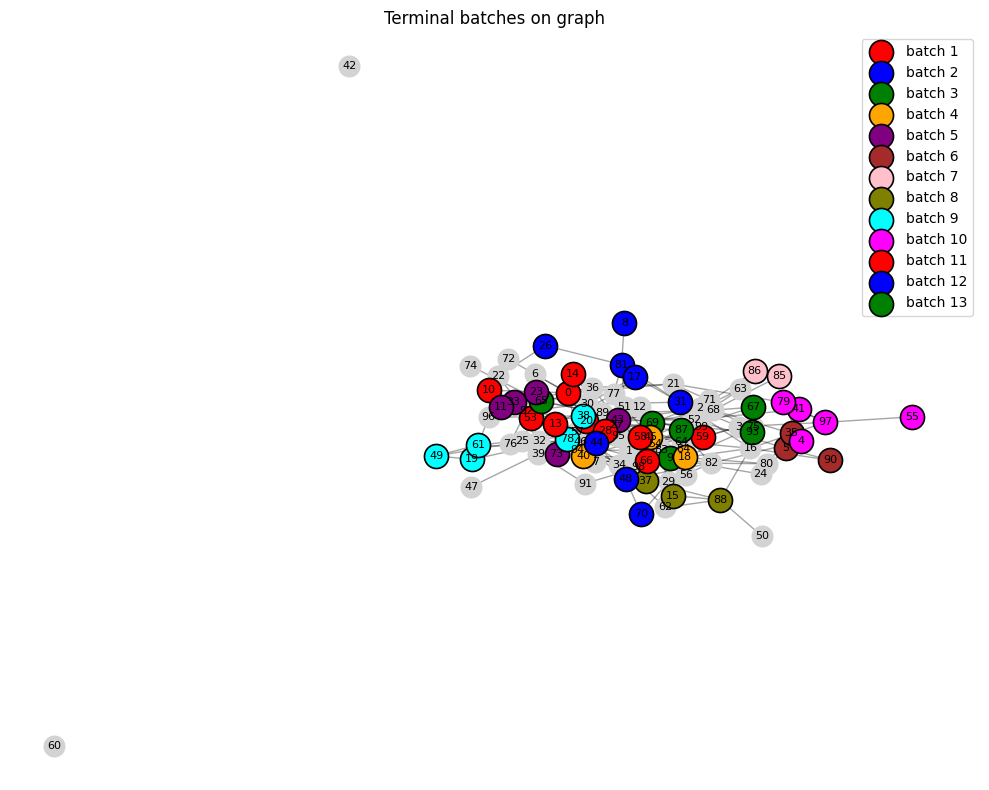

batch sizes: [6, 5, 1, 6, 5, 1, 5, 6, 5, 6, 3, 1]
min batch size used: 1
max batch size: 6
used large-bias fallback: True
terminal batches: [[59, 3, 54, 58, 66, 71], [79, 4, 82, 48, 80], [10], [65, 6, 25, 74, 96, 30], [20, 39, 13, 47, 91], [93], [88, 15, 37, 50, 62], [33, 11, 22, 23, 26, 72], [98, 64, 94, 45, 12], [86, 2, 85, 63, 68, 67], [76, 49, 19], [84]]
terminals: [59, 3, 54, 58, 66, 71, 79, 4, 82, 48, 80, 10, 65, 6, 25, 74, 96, 30, 20, 39, 13, 47, 91, 93, 88, 15, 37, 50, 62, 33, 11, 22, 23, 26, 72, 98, 64, 94, 45, 12, 86, 2, 85, 63, 68, 67, 76, 49, 19, 84]
cross-batch terminal edges: []


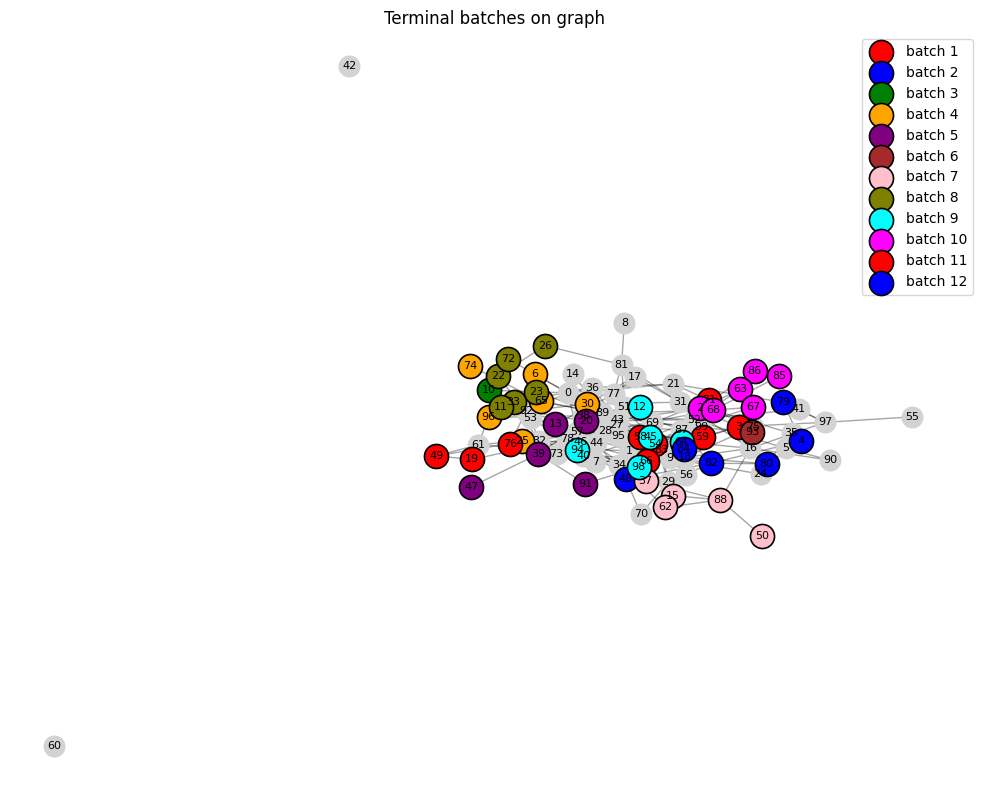

batch sizes: [6, 6, 2, 6, 3, 5, 6, 5, 2, 4, 3, 1, 1]
min batch size used: 1
max batch size: 6
used large-bias fallback: True
terminal batches: [[48, 44, 46, 70, 82, 30], [81, 8, 26, 77, 22, 45], [75, 68], [39, 20, 47, 91, 0, 95], [76, 49, 19], [2, 43, 63, 86, 23], [94, 69, 98, 65, 71, 93], [88, 15, 37, 50, 62], [58, 54], [55, 97, 3, 41], [5, 24, 90], [7], [33]]
terminals: [48, 44, 46, 70, 82, 30, 81, 8, 26, 77, 22, 45, 75, 68, 39, 20, 47, 91, 0, 95, 76, 49, 19, 2, 43, 63, 86, 23, 94, 69, 98, 65, 71, 93, 88, 15, 37, 50, 62, 58, 54, 55, 97, 3, 41, 5, 24, 90, 7, 33]
cross-batch terminal edges: []


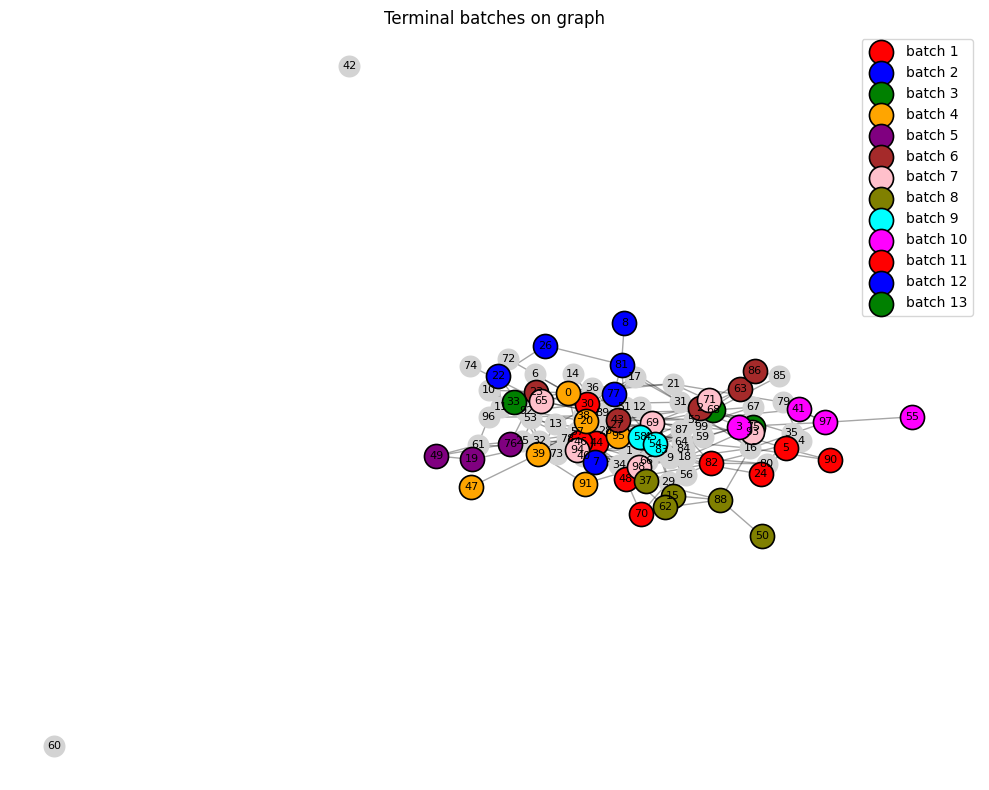

batch sizes: [4, 5, 7, 7, 7, 3, 7, 4, 3, 3]
min batch size used: 3
max batch size: 7
used large-bias fallback: True
terminal batches: [[85, 68, 86, 28], [84, 18, 95, 99, 7], [3, 59, 97, 71, 41, 55, 79], [81, 8, 17, 26, 77, 30, 22], [70, 29, 48, 37, 82, 46, 88], [91, 39, 47], [19, 49, 61, 94, 96, 65, 74], [12, 43, 23, 64], [24, 5, 90], [0, 10, 14]]
terminals: [85, 68, 86, 28, 84, 18, 95, 99, 7, 3, 59, 97, 71, 41, 55, 79, 81, 8, 17, 26, 77, 30, 22, 70, 29, 48, 37, 82, 46, 88, 91, 39, 47, 19, 49, 61, 94, 96, 65, 74, 12, 43, 23, 64, 24, 5, 90, 0, 10, 14]
cross-batch terminal edges: []


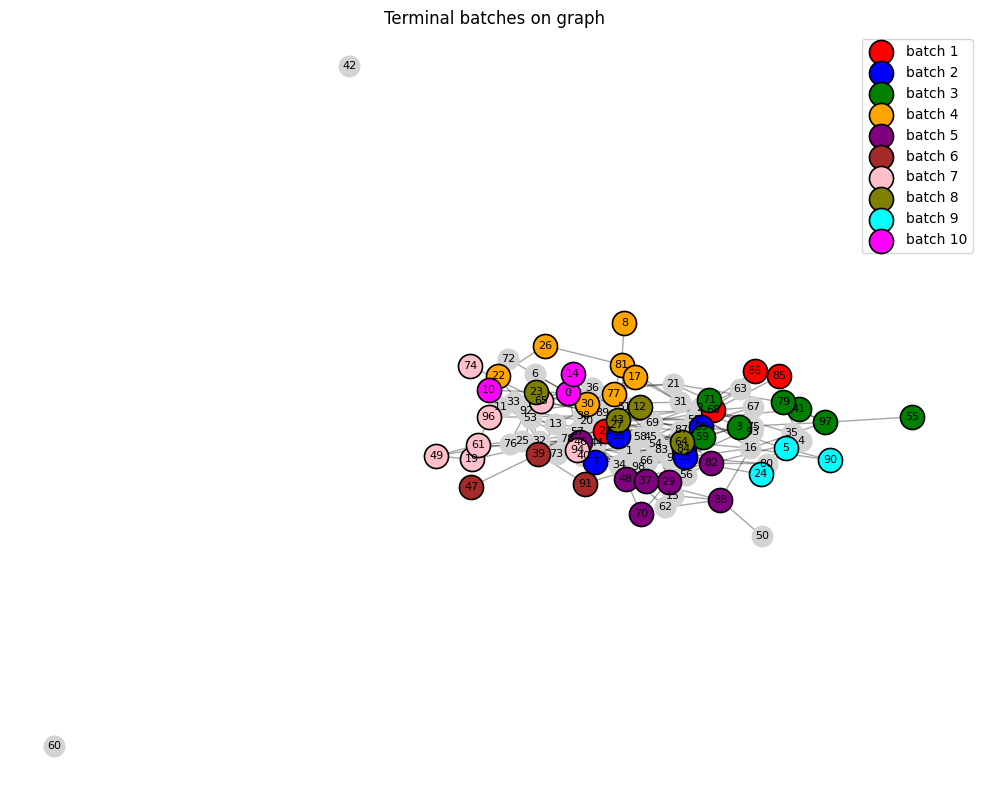

batch sizes: [2, 5, 4, 4, 1, 5, 1, 4, 5, 4, 4, 4, 2, 2, 1, 1, 1]
min batch size used: 1
max batch size: 5
used large-bias fallback: True
terminal batches: [[63, 2], [69, 65, 71, 93, 94], [12, 27, 45, 0], [19, 49, 76, 28], [85], [48, 44, 70, 82, 30], [42], [79, 97, 3, 41], [23, 11, 22, 33, 26], [66, 95, 51, 84], [24, 5, 35, 90], [15, 88, 37, 50], [73, 7], [47, 39], [8], [60], [67]]
terminals: [63, 2, 69, 65, 71, 93, 94, 12, 27, 45, 0, 19, 49, 76, 28, 85, 48, 44, 70, 82, 30, 42, 79, 97, 3, 41, 23, 11, 22, 33, 26, 66, 95, 51, 84, 24, 5, 35, 90, 15, 88, 37, 50, 73, 7, 47, 39, 8, 60, 67]
cross-batch terminal edges: []


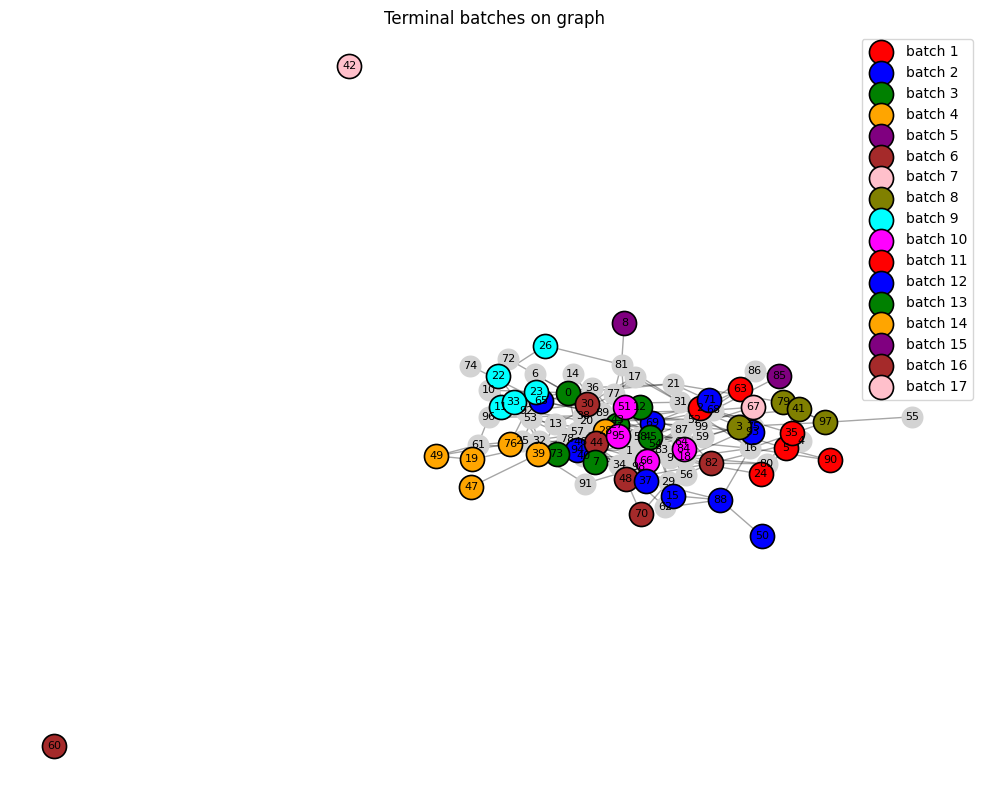

batch sizes: [5, 5, 4, 5, 4, 4, 3, 4, 5, 3, 1, 3, 1, 2, 1]
min batch size used: 1
max batch size: 5
used large-bias fallback: True
terminal batches: [[19, 49, 78, 61, 76], [36, 0, 21, 33, 43], [87, 34, 51, 67], [41, 52, 97, 5, 63], [6, 65, 69, 74], [88, 15, 37, 50], [53, 22, 26], [17, 31, 77, 13], [18, 75, 80, 84, 98], [48, 44, 70], [91], [59, 58, 66], [42], [85, 86], [47]]
terminals: [19, 49, 78, 61, 76, 36, 0, 21, 33, 43, 87, 34, 51, 67, 41, 52, 97, 5, 63, 6, 65, 69, 74, 88, 15, 37, 50, 53, 22, 26, 17, 31, 77, 13, 18, 75, 80, 84, 98, 48, 44, 70, 91, 59, 58, 66, 42, 85, 86, 47]
cross-batch terminal edges: []


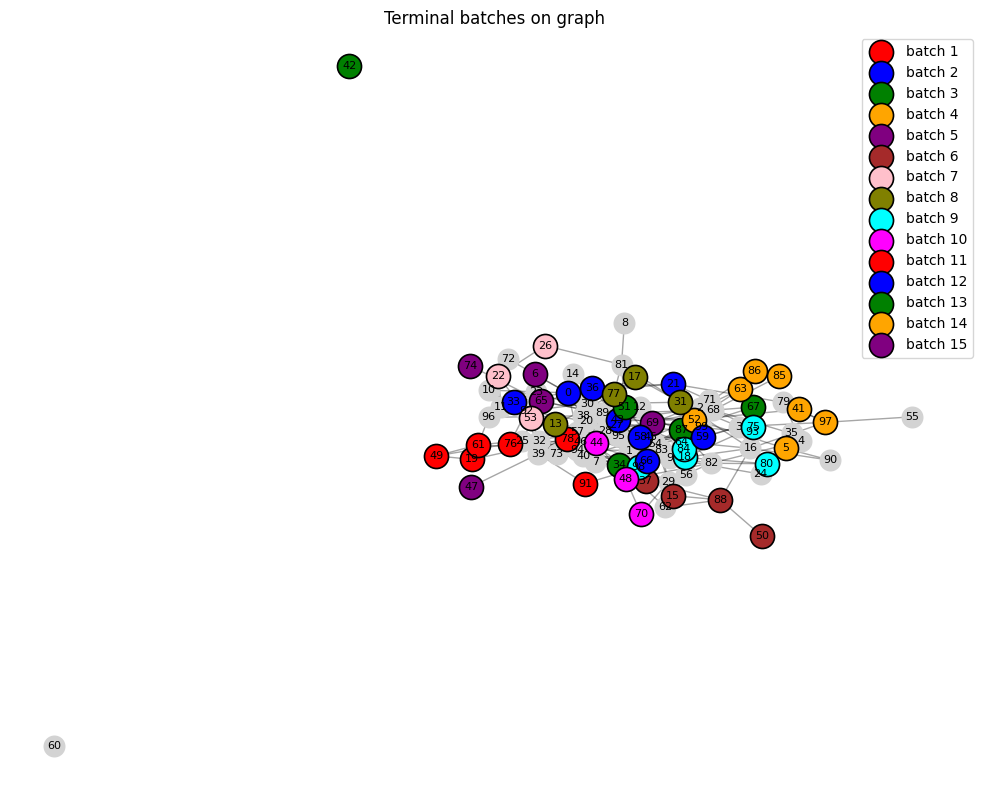

batch sizes: [1, 3, 6, 7, 7, 7, 1, 3, 6, 6, 2, 1]
min batch size used: 1
max batch size: 7
used large-bias fallback: True
terminal batches: [[65], [44, 30, 48], [0, 10, 14, 20, 21, 27], [5, 24, 35, 90, 9, 80, 68], [19, 49, 61, 76, 94, 40, 32], [55, 97, 3, 41, 59, 58, 66], [93], [64, 43, 23], [15, 88, 37, 50, 62, 29], [51, 81, 8, 26, 77, 22], [99, 84], [4]]
terminals: [65, 44, 30, 48, 0, 10, 14, 20, 21, 27, 5, 24, 35, 90, 9, 80, 68, 19, 49, 61, 76, 94, 40, 32, 55, 97, 3, 41, 59, 58, 66, 93, 64, 43, 23, 15, 88, 37, 50, 62, 29, 51, 81, 8, 26, 77, 22, 99, 84, 4]
cross-batch terminal edges: []


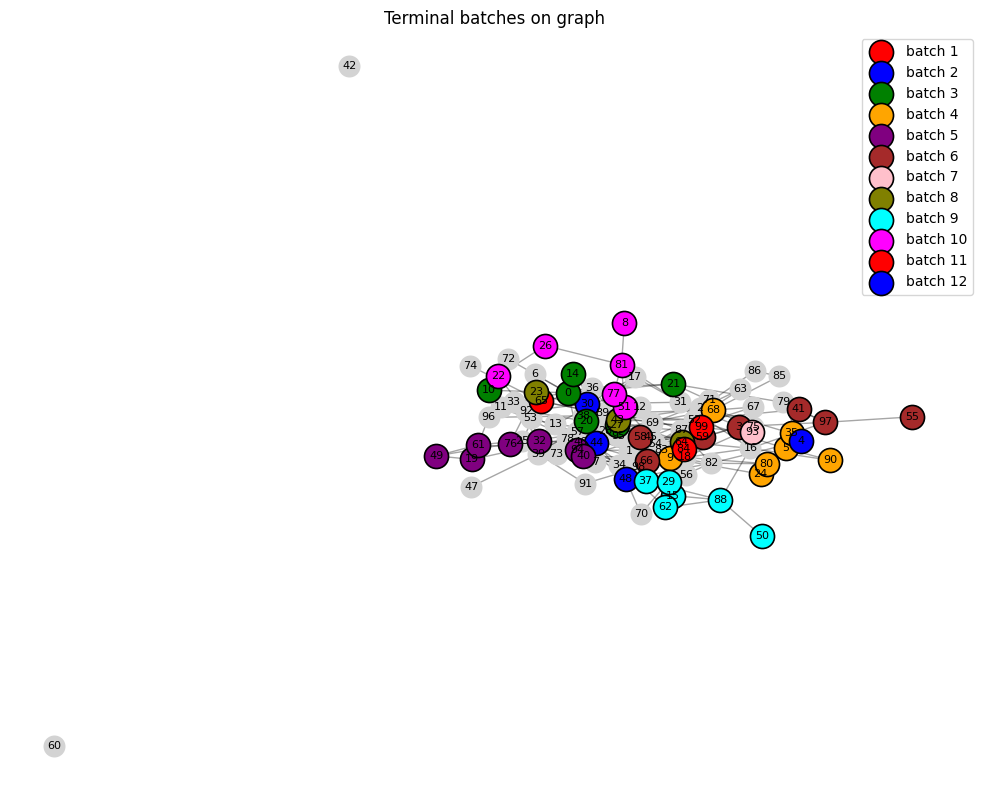

In [81]:
G = nx.erdos_renyi_graph(100, 0.04, seed=1)
print(f"Edges: {len(G.edges())}")

for rep in range(10):
  try:
    result = generate_terminals_with_fallback(
      G=G,
      terminal_count=50,
      distribution="uniform",
      random_seed=rep,
      max_assignment_retries=1000
    )

    print("batch sizes:", result["batch_sizes"])
    print("min batch size used:", result["min_batch_size"])
    print("max batch size:", result["max_batch_size"])
    print("used large-bias fallback:", result["used_large_bias"])
    print("terminal batches:", result["terminal_batches"])
    print("terminals:", result["terminals"])

    print("cross-batch terminal edges:", find_cross_batch_terminal_edges(G, result["terminal_batches"]))
    visualize_terminal_batches(G, result["terminal_batches"])

  except RuntimeError as error:
    print(f"rep {rep} failed: {error}")

In [69]:
G.edges()

EdgeView([(0, 10), (0, 14), (0, 20), (0, 21), (0, 27), (0, 36), (0, 57), (0, 72), (0, 73), (1, 19), (1, 40), (1, 52), (1, 53), (1, 68), (2, 6), (2, 7), (2, 35), (2, 37), (2, 59), (3, 22), (3, 42), (3, 47), (3, 65), (3, 66), (4, 36), (4, 64), (5, 19), (5, 33), (6, 12), (6, 42), (6, 45), (7, 14), (7, 25), (7, 42), (7, 74), (8, 14), (8, 47), (9, 17), (9, 53), (9, 62), (9, 65), (9, 69), (10, 46), (10, 53), (10, 58), (11, 29), (12, 27), (12, 54), (12, 60), (13, 44), (13, 66), (14, 57), (15, 55), (15, 56), (15, 66), (15, 72), (16, 21), (16, 67), (17, 32), (17, 48), (17, 50), (17, 51), (18, 38), (18, 63), (18, 74), (19, 26), (19, 57), (21, 47), (21, 69), (22, 25), (22, 46), (23, 27), (23, 40), (23, 53), (24, 36), (24, 40), (24, 60), (24, 62), (24, 65), (24, 69), (25, 35), (25, 36), (25, 68), (26, 34), (26, 38), (27, 31), (27, 36), (27, 47), (27, 66), (27, 71), (27, 74), (28, 29), (28, 43), (28, 56), (28, 74), (29, 58), (30, 54), (30, 67), (31, 64), (31, 67), (32, 44), (33, 38), (33, 46), (33,

In [126]:
NODES = 75

TERMINAL_BUDGETS = [5, 10, 15, 20, 30, 40, 50]
K_CASE_1_BUDGETS = [50, 30, 20, 10]

result = {}

for ter_budgets in TERMINAL_BUDGETS:
  len_terminals = round(NODES * (ter_budgets / 100))

  result[len_terminals] = []

  for k_bud in K_CASE_1_BUDGETS:
    len_k = max(int(len_terminals * (k_bud / 100)), 1)

    if len_k not in result[len_terminals]:
      result[len_terminals].append(len_k)


print(result)

{4: [2, 1], 8: [4, 2, 1], 11: [5, 3, 2, 1], 15: [7, 4, 3, 1], 22: [11, 6, 4, 2], 30: [15, 9, 6, 3], 38: [19, 11, 7, 3]}


In [127]:
NODES = 75

TERMINAL_BUDGETS = [5, 10, 15, 20, 30, 40, 50]
K_CASE_2_BUDGETS = [50, 30, 20, 10]

result = {}

for ter_budgets in TERMINAL_BUDGETS:
  len_terminals = round(NODES * (ter_budgets / 100))

  result[len_terminals] = list()

  for k_bud in K_CASE_2_BUDGETS:
    len_k = max(int((NODES - len_terminals) * (k_bud / 100)), 1)

    if len_k not in result[len_terminals]:
      result[len_terminals].append(len_k)

print(result)


{4: [35, 21, 14, 7], 8: [33, 20, 13, 6], 11: [32, 19, 12, 6], 15: [30, 18, 12, 6], 22: [26, 15, 10, 5], 30: [22, 13, 9, 4], 38: [18, 11, 7, 3]}
